# Random Forest: Tuning & Feature Selection Experiments

RF is the nonlinear benchmark for this project. Three experiments, focused on what's actually uncertain for RF.

**Experiment Plan:**
1. Remove Accident Type — measure the impact on RF specifically
2. Feature importance redistribution — see where the freed importance budget goes without the dominant feature
3. GridSearchCV — optimize tree hyperparameters on the locked 5-feature set

**Why fewer experiments than LR:** LR tuning established that Track Type beats Signalization (0.409 vs 0.378 F1) and that RUCC_Metro_Adjacency ties RUCC_2023 at identical performance. These are feature-level findings that hold regardless of model type. The one experiment worth rerunning on RF is Accident Type removal — because whether a nonlinear model can partially compensate through tree splits is a genuinely open question.



## Methodology
- All experiments use 5-fold Stratified CV on the 80% training set
- Primary metric: Weighted F1-score
- Each experiment saves results to JSON in `../results/rf/`
- Random seed 521 throughout

---

## Setup

In [18]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_score, recall_score
)

import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
style.use('tableau-colorblind10')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)

CAUSE_ORDER = ['E', 'H', 'M', 'S', 'T']
CAUSE_LABELS = {
    'E': 'Environmental', 'H': 'Human Factor',
    'M': 'Mechanical', 'S': 'Signal', 'T': 'Track'
}

## Helper Functions

Reusable functions for building pipelines, running CV, saving results, and comparing experiments. RF uses OrdinalEncoder instead of OneHotEncoder because decision trees split on thresholds (feature > X), so they naturally handle ordinal-encoded categories without needing binary columns. This keeps the feature space compact and avoids fragmenting split decisions across many dummy variables.

In [19]:
def build_rf_pipeline(categorical_features, numeric_features, **rf_kwargs):
    """
    Build a sklearn Pipeline: OrdinalEncoder -> RandomForestClassifier.
    
    No StandardScaler needed - trees are scale-invariant. They split on
    rank order, not magnitude, so scaling has no effect on performance.
    
    Parameters
    ----------
    categorical_features : list of str
        Columns to ordinal encode.
    numeric_features : list of str
        Columns to pass through directly.
    **rf_kwargs : dict
        Additional keyword arguments passed to RandomForestClassifier.
    
    Returns
    -------
    Pipeline
    """
    rf_params = {
        'n_estimators': 100,
        'random_state': RANDOM_SEED,
        'n_jobs': -1
    }
    rf_params.update(rf_kwargs)
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', 
                                    unknown_value=-1), 
             categorical_features),
            ('num', 'passthrough', numeric_features)
        ]
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(**rf_params))
    ])
    
    return pipeline


def run_cv_experiment(pipeline, X, y, n_splits=5):
    """
    Run stratified k-fold CV and return per-fold scores and detailed metrics.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    scores = []
    last_y_val = None
    last_y_pred = None
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='weighted')
        scores.append(f1)
        
        last_y_val = y_val
        last_y_pred = y_pred
    
    precision_per_class = precision_score(last_y_val, last_y_pred, average=None,
                                          labels=CAUSE_ORDER, zero_division=0)
    recall_per_class = recall_score(last_y_val, last_y_pred, average=None,
                                    labels=CAUSE_ORDER, zero_division=0)
    f1_per_class = f1_score(last_y_val, last_y_pred, average=None,
                            labels=CAUSE_ORDER, zero_division=0)
    
    per_class = pd.DataFrame({
        'Cause': CAUSE_ORDER,
        'Precision': precision_per_class.round(3),
        'Recall': recall_per_class.round(3),
        'F1': f1_per_class.round(3)
    })
    
    return {
        'scores': [float(s) for s in scores],
        'mean': float(np.mean(scores)),
        'std': float(np.std(scores)),
        'per_class_metrics': per_class,
        'last_y_val': last_y_val,
        'last_y_pred': last_y_pred
    }


def save_experiment(results, features, experiment_name, filepath, **extra_fields):
    """
    Save experiment results to JSON.
    """
    output = {
        'experiment': experiment_name,
        'model': 'Random Forest',
        'features': {
            'categorical': features['categorical'],
            'numeric': features['numeric'],
            'total': len(features['categorical']) + len(features['numeric'])
        },
        'cv_folds': 5,
        'cv_scores': results['scores'],
        'cv_mean': results['mean'],
        'cv_std': results['std'],
        'per_class_metrics': results['per_class_metrics'].to_dict('records'),
        'random_seed': RANDOM_SEED
    }
    output.update(extra_fields)
    
    with open(filepath, 'w') as f:
        json.dump(output, f, indent=4)
    
    print(f"Saved: {filepath}")


def compare_experiments(names, filepaths):
    """
    Load multiple experiment JSONs and display side-by-side comparison.
    """
    print("=" * 65)
    print(f"{'Experiment':<35} {'CV Mean':>10} {'CV Std':>10} {'Features':>8}")
    print("-" * 65)
    
    for name, fp in zip(names, filepaths):
        with open(fp, 'r') as f:
            data = json.load(f)
        
        mean = data.get('cv_mean', 0)
        std = data.get('cv_std', 0)
        
        if isinstance(data.get('features'), dict):
            n_feat = data['features']['total']
        elif isinstance(data.get('features'), list):
            n_feat = len(data['features'])
        else:
            n_feat = '?'
        
        print(f"{name:<35} {mean:>10.4f} {std:>10.4f} {n_feat:>8}")
    
    print("=" * 65)


def plot_cv_comparison(experiments, title='CV Comparison'):
    """
    Plot per-fold F1 scores for multiple experiments.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    folds = np.arange(1, 6)
    
    markers = ['o', 's', '^', 'D', 'v']
    linestyles = ['-', '--', '-.', ':', '-']
    
    for i, (label, scores) in enumerate(experiments):
        mean = np.mean(scores)
        ax.plot(folds, scores, marker=markers[i % len(markers)], 
                linewidth=2, linestyle=linestyles[i % len(linestyles)],
                label=f'{label} (mean={mean:.4f})')
        ax.axhline(y=mean, linestyle=':', alpha=0.3)
    
    ax.set_xlabel('Fold')
    ax.set_ylabel('Weighted F1-Score')
    ax.set_title(title)
    ax.set_xticks(folds)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_per_class_comparison(results_list, labels, title='Per-Class F1 Comparison'):
    """
    Side-by-side per-class F1 bars for multiple experiments.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x = np.arange(len(CAUSE_ORDER))
    n = len(results_list)
    width = 0.8 / n
    hatches = ['//', '..', 'xx', '\\\\', '++']
    
    for i, (df, label) in enumerate(zip(results_list, labels)):
        offset = (i - n/2 + 0.5) * width
        bars = ax.bar(x + offset, df['F1'], width, label=label)
        for bar in bars:
            bar.set_hatch(hatches[i % len(hatches)])
    
    ax.set_xlabel('Cause Category')
    ax.set_ylabel('F1-Score')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}" for c in CAUSE_ORDER])
    ax.legend()
    ax.set_ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## Load Training Data

In [20]:
df_train = pd.read_csv('../../data/splits/train_80.csv', low_memory=False)

target = 'Cause_Category'
y_train = df_train[target].copy()

print(f"Training set: {len(df_train)} rows")
print(f"\nCause_Category distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training set: 27640 rows

Cause_Category distribution:
Cause_Category
H    0.393
M    0.256
T    0.218
E    0.108
S    0.025
Name: proportion, dtype: float64


In [21]:
# Load baseline results for comparison
with open('results/rf/rf_baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

print(f"Baseline RF CV: {baseline_results.get('cv_mean', 'N/A')}")
print(f"Baseline features: {baseline_results.get('features', 'N/A')}")

Baseline RF CV: 0.5507440673638375
Baseline features: {'categorical': ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region'], 'numeric': ['RUCC_2023'], 'total': 6}


---

# Section 1: Feature Validation

## Experiment 1: Remove Accident Type

Phase 3 ARM-CBA analysis flagged Accident Type as a label leakage problem:
- **ARM:** Zero rules generated without it (support 0.005, confidence 0.50, lift 1.0)
- **Chi-Square:** Strongest statistical association with Cause_Category among all features
- **RF baseline Gini importance:** Accident Type consumed 0.485 of the total importance budget — nearly half of all tree splits

LR dropped 0.127 when Accident Type was removed (0.536 → 0.409). This experiment tests whether RF's nonlinear splits can partially compensate — or whether the drop is the same regardless of algorithm.

In [22]:
# Experiment 1: Same 5 features as LR tuning winner (no Accident Type)
cat_features_exp1 = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 
                      'RUCC_Metro_Adjacency']
num_features_exp1 = []

X_exp1 = df_train[cat_features_exp1 + num_features_exp1].copy()

pipeline_exp1 = build_rf_pipeline(cat_features_exp1, num_features_exp1)

print("Experiment 1: RF without Accident Type")
print("-" * 45)
results_exp1 = run_cv_experiment(pipeline_exp1, X_exp1, y_train)

for fold, score in enumerate(results_exp1['scores'], 1):
    print(f"  Fold {fold}: Weighted F1 = {score:.4f}")
print(f"\nCV: {results_exp1['mean']:.4f} +/- {results_exp1['std']:.4f}")

Experiment 1: RF without Accident Type
---------------------------------------------
  Fold 1: Weighted F1 = 0.4273
  Fold 2: Weighted F1 = 0.4150
  Fold 3: Weighted F1 = 0.4171
  Fold 4: Weighted F1 = 0.4184
  Fold 5: Weighted F1 = 0.4273

CV: 0.4210 +/- 0.0053


In [23]:
# Save experiment 1 results
save_experiment(
    results_exp1,
    features={'categorical': cat_features_exp1, 'numeric': num_features_exp1},
    experiment_name='RF Baseline without Accident Type',
    filepath='results/rf/rf_exp_no_accident_type.json',
    notes='Removed Accident Type. LR dropped from 0.536 to 0.409 (-0.127). Comparing RF magnitude.'
)

# Compare against baseline
compare_experiments(
    names=['Baseline (6 features, w/ AT)', 'Without Accident Type (5 features)'],
    filepaths=['results/rf/rf_baseline_results.json', 'results/rf/rf_exp_no_accident_type.json']
)

Saved: results/rf/rf_exp_no_accident_type.json
Experiment                             CV Mean     CV Std Features
-----------------------------------------------------------------
Baseline (6 features, w/ AT)            0.5507     0.0083        6
Without Accident Type (5 features)      0.4210     0.0053        5


In [24]:
# Per-class comparison
print("Per-class metrics (without Accident Type):")
print(results_exp1['per_class_metrics'].to_string(index=False))

print(f"\nClassification report:")
print(classification_report(results_exp1['last_y_val'], results_exp1['last_y_pred'], 
                             labels=CAUSE_ORDER, zero_division=0))

Per-class metrics (without Accident Type):
Cause  Precision  Recall    F1
    E      0.309   0.035 0.063
    H      0.512   0.778 0.617
    M      0.453   0.561 0.501
    S      1.000   0.007 0.014
    T      0.452   0.150 0.226

Classification report:
              precision    recall  f1-score   support

           E       0.31      0.04      0.06       596
           H       0.51      0.78      0.62      2172
           M       0.45      0.56      0.50      1416
           S       1.00      0.01      0.01       139
           T       0.45      0.15      0.23      1205

    accuracy                           0.49      5528
   macro avg       0.55      0.31      0.28      5528
weighted avg       0.47      0.49      0.43      5528



### Experiment 1 Findings

RF dropped 0.130 when Accident Type was removed (0.551 → 0.421), nearly identical to LR's 0.127 drop (0.536 → 0.409). Both a linear model and a nonlinear ensemble lost the same amount of performance — this is a data-level problem, not a model-complexity problem.

**One genuine difference:** RF finds small pockets of minority-class signal that LR cannot. Environmental precision 0.309 (vs LR's 0.000); Signal precision 1.0 on a single correct prediction (vs LR's 0.000). Recall for both remains negligible (Environmental 3.5%, Signal 0.7%), so the effect on weighted F1 is near-zero — but the signal exists and RF can detect it.

**Decision:** Accident Type removal confirmed across both model types. The 5-feature set gives RF a baseline of 0.421 for hyperparameter tuning.

## Experiment 2: Feature Importance Redistribution

In the baseline model, Accident Type consumed 0.485 of the total Gini importance budget — nearly half of all tree splits went through that one feature. With it removed, that budget has to redistribute across the remaining 5 features. This experiment examines where it goes and whether the distribution matches Phase 2 statistical rankings.

In [25]:
# Refit on full training data to get stable importance estimates
pipeline_exp1.fit(X_exp1, y_train)

# Extract feature names after OrdinalEncoder
feature_names = cat_features_exp1 + num_features_exp1

# Get feature importances
importances = pipeline_exp1.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Feature Importance': importances
}).sort_values('Feature Importance', ascending=False)

print("Feature Importance without Accident Type:")
print("-" * 45)
print(importance_df.to_string(index=False))
print(f"\nTotal importance: {importances.sum():.4f}")

Feature Importance without Accident Type:
---------------------------------------------
             Feature  Feature Importance
          Track Type            0.564189
              Region            0.126955
   Weather Condition            0.125703
          Visibility            0.101976
RUCC_Metro_Adjacency            0.081177

Total importance: 1.0000


In [26]:
# Load baseline importance from saved model
baseline_pipeline = joblib.load('models/rf_baseline_pipeline.pkl')
baseline_importances = baseline_pipeline.named_steps['classifier'].feature_importances_

# Get baseline feature names from the OrdinalEncoder
baseline_features = baseline_pipeline.named_steps['preprocessor'].transformers_[0][1].categories_
# The feature names are the column names passed to the pipeline
baseline_feature_names = ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region', 'RUCC_2023']

baseline_imp_dict = dict(zip(baseline_feature_names, baseline_importances))
without_at_imp_dict = dict(zip(importance_df['Feature'], importance_df['Feature Importance']))

print("\nImportance Comparison: With vs Without Accident Type")
print(f"{'Feature':<25} {'With AT':>10} {'Without AT':>12} {'Change':>10}")
print("-" * 60)

# Show shared features first
for feat in importance_df['Feature']:
    with_val = baseline_imp_dict.get(feat, 0)
    without_val = without_at_imp_dict.get(feat, 0)
    change = without_val - with_val
    print(f"{feat:<25} {with_val:>10.3f} {without_val:>12.3f} {change:>+10.3f}")

# Show Accident Type's removed contribution
if 'Accident Type' in baseline_imp_dict:
    print(f"{'Accident Type':<25} {baseline_imp_dict['Accident Type']:>10.3f} {'removed':>12} {'':>10}")


Importance Comparison: With vs Without Accident Type
Feature                      With AT   Without AT     Change
------------------------------------------------------------
Track Type                     0.154        0.564     +0.410
Region                         0.079        0.127     +0.048
Weather Condition              0.076        0.126     +0.049
Visibility                     0.069        0.102     +0.033
RUCC_Metro_Adjacency           0.000        0.081     +0.081
Accident Type                  0.485      removed           


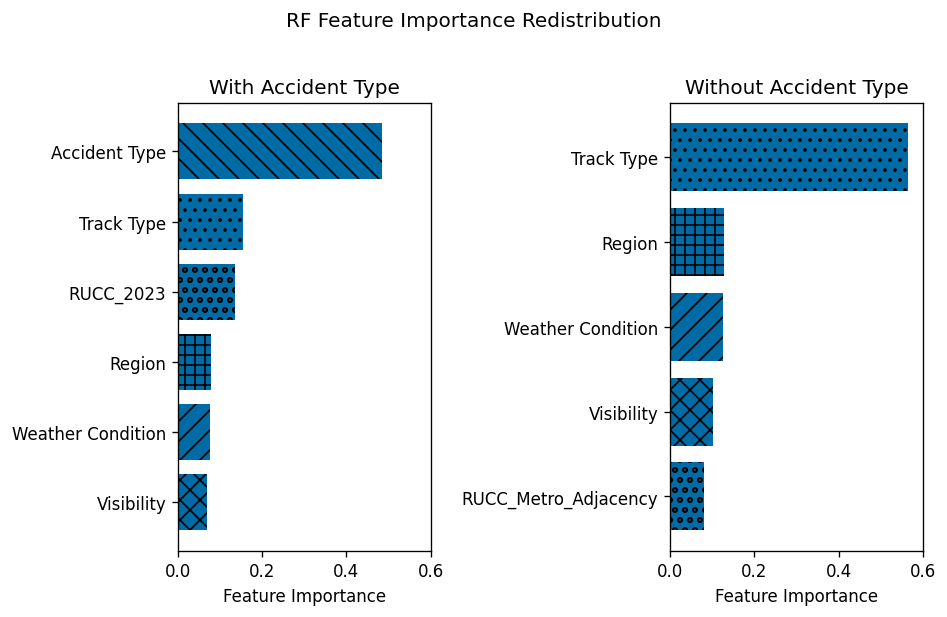

In [27]:
# Side-by-side importance bar chart
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# Define consistent hatch per feature
feature_hatches = {
    'Weather Condition': '//',
    'Track Type': '..',
    'Visibility': 'xx',
    'Accident Type': '\\\\',
    'Region': '++',
    'RUCC_Metro_Adjacency': 'oo',
    'RUCC_2023': 'oo'
}

# Left: With Accident Type (baseline)
baseline_imp_df = pd.DataFrame({
    'Feature': baseline_feature_names,
    'Feature Importance': baseline_importances
}).sort_values('Feature Importance', ascending=False)

bars_left = axes[0].barh(baseline_imp_df['Feature'], baseline_imp_df['Feature Importance'])
for bar, feat in zip(bars_left, baseline_imp_df['Feature']):
    bar.set_hatch(feature_hatches.get(feat, ''))
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('With Accident Type')
axes[0].set_xlim(0, 0.6)
axes[0].invert_yaxis()

# Right: Without Accident Type
bars_right = axes[1].barh(importance_df['Feature'], importance_df['Feature Importance'])
for bar, feat in zip(bars_right, importance_df['Feature']):
    bar.set_hatch(feature_hatches.get(feat, ''))
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Without Accident Type')
axes[1].set_xlim(0, 0.6)
axes[1].invert_yaxis()

fig.suptitle('RF Feature Importance Redistribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Note on RUCC encoding:** The baseline uses RUCC_2023 (raw, 9 codes) and the updated model uses RUCC_Metro_Adjacency (binned, 3 categories) — a change established in LR Experiment 3. The charts reflect two simultaneous changes: Accident Type removal and RUCC rebinning. The RUCC importance drop (0.130 → 0.081) is partly attributable to fewer splitting opportunities (3 bins vs 9 codes), not only importance redistribution from Accident Type removal.

### Experiment 2 Findings

**The headline:** Track Type jumped from 0.154 to 0.564, absorbing the lion's share of Accident Type's freed importance budget. It now accounts for more than half of all split decisions in the forest. The remaining four features spread relatively evenly: Region (0.127), Weather Condition (0.126), Visibility (0.102), RUCC_Metro_Adjacency (0.081).

**Comparison to Phase 2 Chi-Square rankings:**

| Feature | Chi-Square Rank | Gini Importance (no AT) |
|---|---|---|
| Track Type | 1st (0.21) | 1st (0.564) |
| RUCC_Metro_Adjacency | 2nd (0.077) | 5th (0.081) |
| Region | 3rd (0.05) | 2nd (0.127) |
| Visibility | 4th (0.04) | 4th (0.102) |
| Weather Condition | 5th (0.04) | 3rd (0.126) |

Track Type leads in both rankings — the strongest predictor by either measure. Chi-Square measures statistical association between the feature and target in the raw data; Gini importance measures usefulness for tree splits. That they agree on first place is meaningful. The middle features shuffled slightly, which is expected. RUCC dropped from 2nd to 5th — 3 bins offer fewer splitting opportunities for trees than Region's 4 or Weather's 5 categories.

The distribution is concentrated but healthier than the baseline. Accident Type had taken 0.485; Track Type now takes 0.564 — higher proportionally, but the other four features are more evenly spread (0.08–0.13) than they were under Accident Type's shadow (all compressed below 0.15).

---

# Section 2: Hyperparameter Tuning

## Experiment 3: GridSearchCV

Grid search across 216 combinations: tree count (100, 200, 300), depth limit (None, 10, 20, 30), min leaf size (1, 5, 10), feature sampling (sqrt, log2, all features), and class weighting (None, balanced). 1,080 total fits.

The baseline uses sklearn defaults (100 trees, no depth limit, min_samples_leaf=1, sqrt features). The open question: does any configuration push past the 0.421 established in Experiment 1?

**What each hyperparameter controls:**
- **n_estimators:** Number of trees in the forest. More trees generally improve performance up to a point of diminishing returns, then just slow down training. 100 is sklearn's default; we test whether 200 or 300 helps.
- **max_depth:** Maximum depth of each tree. `None` lets trees grow until all leaves are pure, which risks overfitting. Setting a limit (like 10 or 20) forces simpler trees that may generalize better.
- **min_samples_leaf:** Minimum number of samples required at a leaf node. Higher values (like 5 or 10) prevent the tree from creating leaves for tiny subgroups, which reduces overfitting. Default is 1, meaning a leaf can represent a single training example.
- **max_features:** Number of features considered at each split. `sqrt` (default) considers the square root of total features at each split, adding randomness that decorrelates trees. `log2` considers even fewer, increasing diversity further. `None` considers all features at every split, reducing randomness.
- **class_weight:** How to weight classes during training. `None` treats all classes equally. `balanced` weights inversely proportional to class frequency, giving rare classes (S, E) more influence. LR and RF baselines both showed `balanced` hurting weighted F1, but it's worth retesting with the new feature set.

In [28]:
# Locked feature set from LR tuning experiments
cat_features_final = ['Weather Condition', 'Track Type', 'Visibility', 'Region', 
                       'RUCC_Metro_Adjacency']
num_features_final = []

X_final = df_train[cat_features_final + num_features_final].copy()

# Build base pipeline for GridSearch
pipeline_grid = build_rf_pipeline(cat_features_final, num_features_final)

# Define parameter grid
# Strategic grid - test the most impactful hyperparameters without
# combinatorial explosion. 
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': [None, 'balanced']
}

# Count total combinations
n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)

print(f"Parameter combinations: {n_combos}")
print(f"Total fits (5-fold CV): {n_combos * 5}")
print(f"\nThis may take several minutes...\n")

grid_search = GridSearchCV(
    pipeline_grid,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_final, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Parameter combinations: 216
Total fits (5-fold CV): 1080

This may take several minutes...

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters: {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}
Best CV score: 0.4213


In [29]:
# Display top 15 results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_display = grid_results[['param_classifier__n_estimators', 
                              'param_classifier__max_depth',
                              'param_classifier__min_samples_leaf',
                              'param_classifier__max_features',
                              'param_classifier__class_weight',
                              'mean_test_score', 'std_test_score', 
                              'rank_test_score']]
grid_display = grid_display.sort_values('rank_test_score')
grid_display.columns = ['Trees', 'Depth', 'Min Leaf', 'Max Feat', 
                          'Weight', 'Mean F1', 'Std F1', 'Rank']

# Clean up NaN display
grid_display['Weight'] = grid_display['Weight'].fillna('None')
grid_display['Depth'] = grid_display['Depth'].fillna('None')
grid_display['Max Feat'] = grid_display['Max Feat'].fillna('all')

print("GridSearchCV Results - Top 15 (sorted by rank):")
print(grid_display.head(15).to_string(index=False))

# Show bottom 3 for contrast
print(f"\nBottom 3:")
print(grid_display.tail(3).to_string(index=False))

print(f"\n{len(grid_display)} total configurations tested.")
print(f"Top-to-bottom F1 range: {grid_display['Mean F1'].max():.4f} to {grid_display['Mean F1'].min():.4f}")

GridSearchCV Results - Top 15 (sorted by rank):
 Trees Depth  Min Leaf Max Feat Weight  Mean F1   Std F1  Rank
   300  None         1     sqrt   None 0.421349 0.006727     1
   300    20         1     sqrt   None 0.421349 0.006727     1
   300    30         1     sqrt   None 0.421349 0.006727     1
   300    30         1     log2   None 0.421349 0.006727     1
   300    20         1     log2   None 0.421349 0.006727     1
   300  None         1     log2   None 0.421349 0.006727     1
   300    10         1      all   None 0.421327 0.005977     7
   300    20         1      all   None 0.421120 0.006419     8
   300  None         1      all   None 0.421120 0.006419     8
   300    30         1      all   None 0.421120 0.006419     8
   100    10         1      all   None 0.421036 0.005739    11
   200    30         1     log2   None 0.421000 0.006070    12
   200    30         1     sqrt   None 0.421000 0.006070    12
   200    20         1     log2   None 0.421000 0.006070    12
   200 

In [30]:
# Run CV with best params for detailed metrics
best_params = grid_search.best_params_
pipeline_best = build_rf_pipeline(
    cat_features_final, num_features_final,
    n_estimators=best_params['classifier__n_estimators'],
    max_depth=best_params['classifier__max_depth'],
    min_samples_leaf=best_params['classifier__min_samples_leaf'],
    max_features=best_params['classifier__max_features'],
    class_weight=best_params['classifier__class_weight']
)

results_exp3 = run_cv_experiment(pipeline_best, X_final, y_train)

print(f"Best GridSearch RF CV: {results_exp3['mean']:.4f} +/- {results_exp3['std']:.4f}")
print(f"\nPer-class metrics:")
print(results_exp3['per_class_metrics'].to_string(index=False))

print(f"\nClassification report:")
print(classification_report(results_exp3['last_y_val'], results_exp3['last_y_pred'], 
                             labels=CAUSE_ORDER, zero_division=0))

Best GridSearch RF CV: 0.4213 +/- 0.0067

Per-class metrics:
Cause  Precision  Recall    F1
    E      0.365   0.039 0.070
    H      0.513   0.774 0.617
    M      0.456   0.568 0.506
    S      0.500   0.007 0.014
    T      0.438   0.154 0.227

Classification report:
              precision    recall  f1-score   support

           E       0.37      0.04      0.07       596
           H       0.51      0.77      0.62      2172
           M       0.46      0.57      0.51      1416
           S       0.50      0.01      0.01       139
           T       0.44      0.15      0.23      1205

    accuracy                           0.49      5528
   macro avg       0.45      0.31      0.29      5528
weighted avg       0.47      0.49      0.43      5528



In [31]:
# Save results
save_experiment(
    results_exp3,
    features={'categorical': cat_features_final, 'numeric': num_features_final},
    experiment_name='RF GridSearchCV (5 features, no Accident Type)',
    filepath='results/rf/rf_tuned_gridsearch.json',
    best_params={k.replace('classifier__', ''): str(v) for k, v in best_params.items()},
    n_configurations_tested=n_combos
)

Saved: results/rf/rf_tuned_gridsearch.json


Experiment                             CV Mean     CV Std Features
-----------------------------------------------------------------
Baseline (6 feat, w/ AT)                0.5507     0.0083        6
No Accident Type (5 feat)               0.4210     0.0053        5
GridSearch Tuned (5 feat)               0.4213     0.0067        5


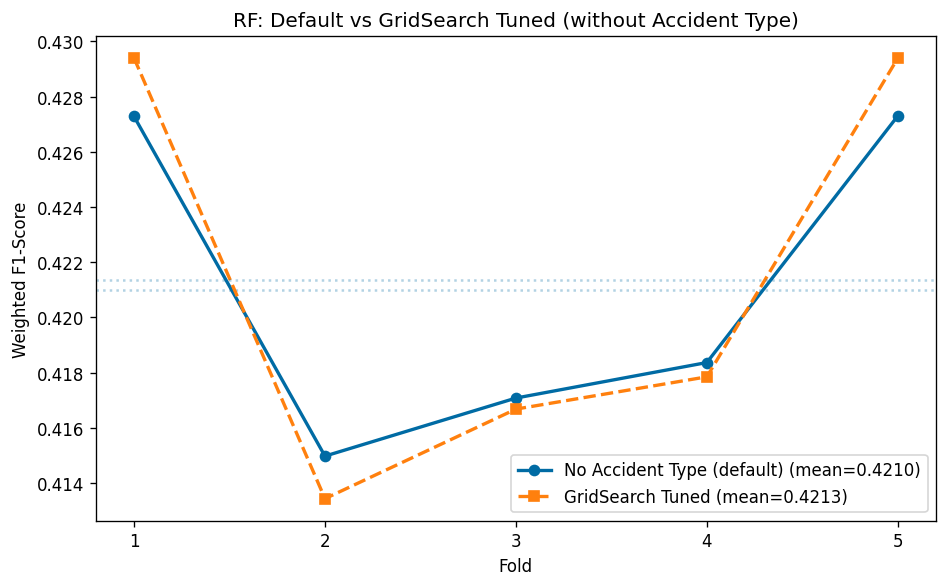

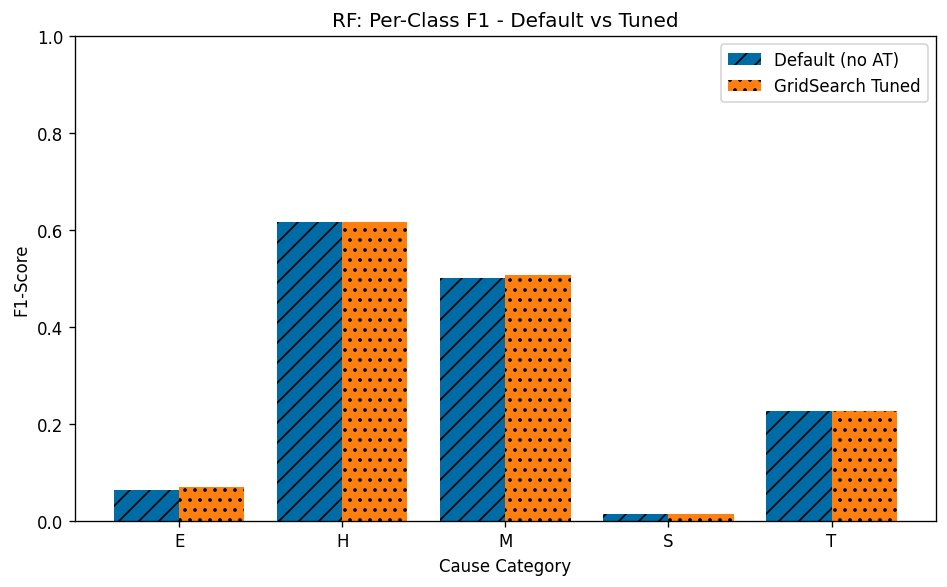

In [32]:
# Compare all RF experiments
compare_experiments(
    names=['Baseline (6 feat, w/ AT)', 'No Accident Type (5 feat)', 'GridSearch Tuned (5 feat)'],
    filepaths=[
        'results/rf/rf_baseline_results.json',
        'results/rf/rf_exp_no_accident_type.json',
        'results/rf/rf_tuned_gridsearch.json'
    ]
)

# CV score comparison plot
plot_cv_comparison(
    experiments=[
        ('No Accident Type (default)', results_exp1['scores']),
        ('GridSearch Tuned', results_exp3['scores'])
    ],
    title='RF: Default vs GridSearch Tuned (without Accident Type)'
)

# Per-class comparison
plot_per_class_comparison(
    [results_exp1['per_class_metrics'], results_exp3['per_class_metrics']],
    ['Default (no AT)', 'GridSearch Tuned'],
    title='RF: Per-Class F1 - Default vs Tuned'
)

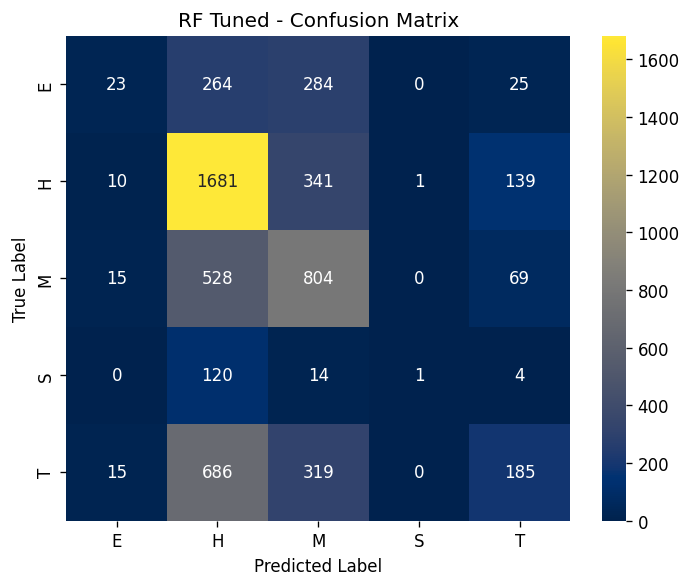

In [33]:
# Confusion matrix for best model
cm = confusion_matrix(results_exp3['last_y_val'], results_exp3['last_y_pred'], 
                       labels=CAUSE_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis',
            xticklabels=CAUSE_ORDER, yticklabels=CAUSE_ORDER, ax=ax)
ax.set_title('RF Tuned - Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### Experiment 3 Findings

Best configuration: 300 trees, no depth limit, min_samples_leaf=1, max_features='sqrt', no class weighting — essentially sklearn defaults with more trees. Best score: 0.4213 vs 0.4210 from the default 100-tree model in Experiment 1. A 0.0003 gain is noise.

**What the grid revealed:**

- **n_estimators:** 300 trees edged 100 and 200, but differences are in the 4th decimal place. The forest was already at the plateau of diminishing returns.
- **max_depth:** No limit, depth=20, and depth=30 all tied. With only 5 features, trees are naturally shallow — there isn't enough feature space to build complex trees that would benefit from pruning.
- **max_features:** `sqrt` and `log2` tied because with 5 features, √5 ≈ 2.2 and log₂(5) ≈ 2.3 — both round to 2 features per split. They are functionally identical at this feature count.
- **class_weight='balanced':** Absent from the top 15, consistent with every prior experiment. Class weighting degraded performance to 0.33 at the bottom of the grid.

**Takeaway:** The 0.421 ceiling is a feature limitation, not a hyperparameter limitation. RF's nonlinear splits give it a marginal edge over LR (0.421 vs 0.409), but 216 configurations could not push past the fundamental constraint of 5 categorical features with limited discriminative power for minority classes.

---

## Save Best Model

Refit the best RF configuration on the full 80% training set and save for final evaluation.

In [35]:
# Refit best pipeline on full training data
pipeline_best.fit(X_final, y_train)

# Save pipeline
joblib.dump(pipeline_best, 'models/rf_tuned_pipeline.pkl')
print(f"Saved: models/rf_tuned_pipeline.pkl")

# Print final feature importance from best model
importances_tuned = pipeline_best.named_steps['classifier'].feature_importances_
importance_tuned_df = pd.DataFrame({
    'Feature': cat_features_final,
    'Feature Importance': importances_tuned
}).sort_values('Feature Importance', ascending=False)

print(f"\nFeature importance (tuned model):")
print(importance_tuned_df.to_string(index=False))

Saved: models/rf_tuned_pipeline.pkl

Feature importance (tuned model):
             Feature  Feature Importance
          Track Type            0.561792
   Weather Condition            0.129944
              Region            0.123924
          Visibility            0.103072
RUCC_Metro_Adjacency            0.081267


---

## Final Summary

In [36]:
# Load and compare all RF experiments
import os

rf_results_dir = 'results/rf/'
all_files = sorted([f for f in os.listdir(rf_results_dir) if f.endswith('.json')])

print("=" * 75)
print(f"{'Experiment':<45} {'CV Mean':>10} {'CV Std':>10} {'Features':>8}")
print("-" * 75)

for f in all_files:
    filepath = os.path.join(rf_results_dir, f)
    with open(filepath, 'r') as fh:
        data = json.load(fh)
    
    name = data.get('experiment', f.replace('.json', ''))
    mean = data.get('cv_mean', 0)
    std = data.get('cv_std', 0)
    
    if isinstance(data.get('features'), dict):
        n_feat = data['features']['total']
    elif isinstance(data.get('features'), list):
        n_feat = len(data['features'])
    else:
        n_feat = '?'
    
    print(f"{name:<45} {mean:>10.4f} {std:>10.4f} {n_feat:>8}")

print("=" * 75)

Experiment                                       CV Mean     CV Std Features
---------------------------------------------------------------------------
RF Baseline (with Accident Type)                  0.5507     0.0083        6
RF Baseline without Accident Type                 0.4210     0.0053        5
Random Forest Final Test Evaluation               0.4213     0.0067        ?
RF GridSearchCV (5 features, no Accident Type)     0.4213     0.0067        5


## Conclusions

This notebook validated the Accident Type removal decision on RF and optimized hyperparameters across 216 configurations. Three experiments confirmed that the 0.42 F1 ceiling is driven by the feature set, not the model.

**Best RF configuration:** 300 trees, no depth limit, min_samples_leaf=1, max_features='sqrt', no class weighting — sklearn defaults with more trees — on 5 features: Weather Condition, Track Type, Visibility, Region, RUCC_Metro_Adjacency.

**Key findings:**

1. **Removing Accident Type dropped RF by 0.130 (0.551 → 0.421), matching LR's 0.127 drop exactly.** A linear model and a nonlinear ensemble lost the same amount of performance — Accident Type's dominance is a data problem that model complexity cannot solve.

2. **Track Type absorbed the majority of the freed importance budget, jumping from 0.154 to 0.564.** It now drives more than half of all tree splits. Feature importance rankings largely align with Phase 2 Chi-Square rankings — Track Type leads both. RUCC_Metro_Adjacency dropped from 2nd (Chi-Square) to 5th (Gini), as its 3-bin encoding offers fewer tree-splitting opportunities than finer-grained categorical features.

3. **216 hyperparameter configurations produced no meaningful improvement.** Best tuned score (0.4213) beat the default (0.4210) by 0.0003. Depth limiting had no effect on a 5-feature dataset. `sqrt` and `log2` feature sampling were functionally identical (both select 2 features per split). Class weighting hurt performance again.

4. **RF's advantage over LR is real but small: 0.421 vs 0.409 on the same 5 features.** RF's nonlinear splits detect faint minority-class signal (non-zero Environmental and Signal precision) that LR cannot. But 216 configurations could not widen that gap. On this feature set, algorithm choice matters far less than the features themselves.

---
*Model saved:* `models/rf_tuned_pipeline.pkl` · *Results:* `results/rf/`